<a href="https://colab.research.google.com/github/LuisTT0903/Processamento-de-Sinais1/blob/main/Pratica3Quest%C3%A3o5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

a=0.7, L=1: Ey/Ex=0.9515  max|y|=0.994


a=0.7, L=4: Ey/Ex=1.3353  max|y|=1.026


a=0.7, L=10: Ey/Ex=1.3058  max|y|=1.038


a=0.9, L=1: Ey/Ex=1.0490  max|y|=0.916


a=0.9, L=4: Ey/Ex=1.1024  max|y|=0.888


a=0.9, L=10: Ey/Ex=1.0917  max|y|=0.901


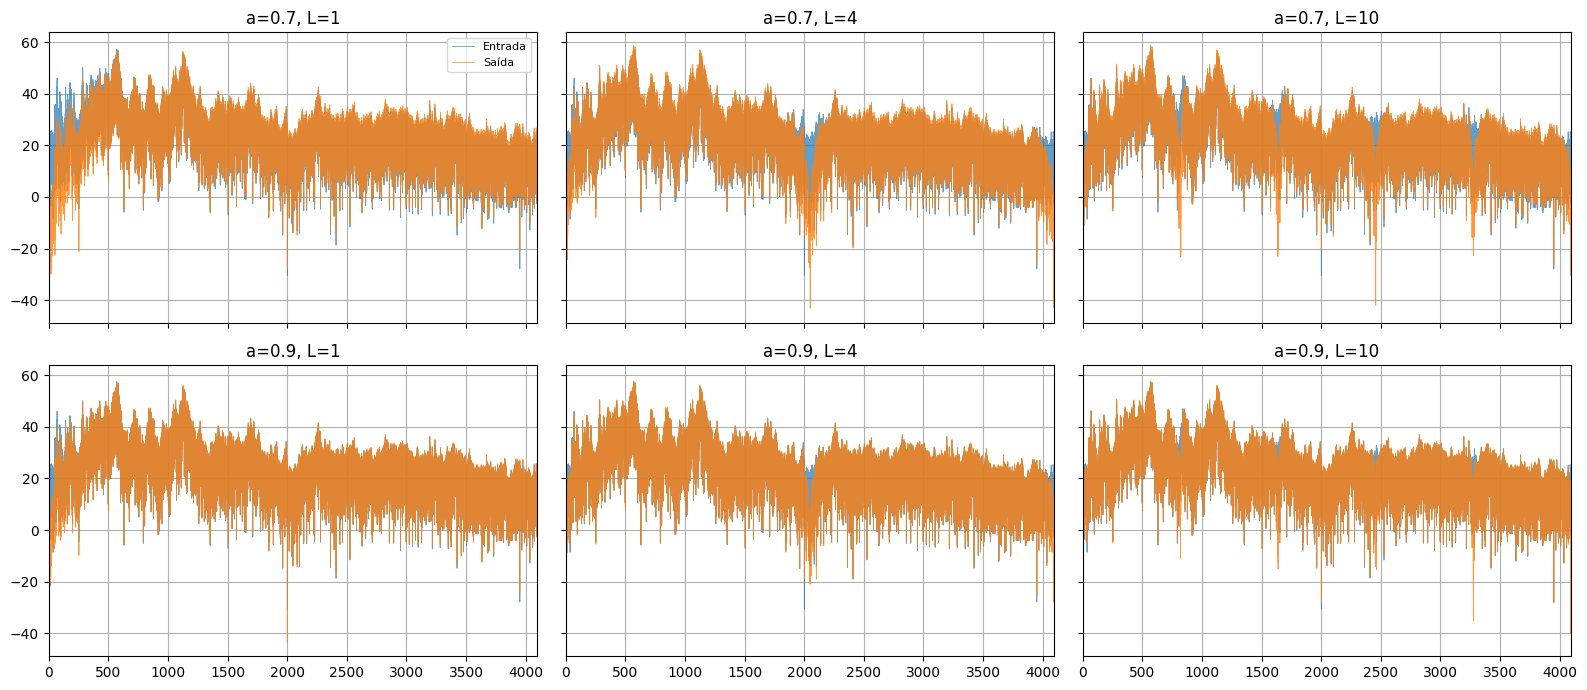

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import urllib.request
from scipy.io import wavfile
from IPython.display import Audio, display

url = "https://raw.githubusercontent.com/LuisTT0903/Processamento-de-Sinais1/main/Aula_03/Audios_Usados/handel.wav"
urllib.request.urlretrieve(url, "handel.wav")
fs, x_int = wavfile.read("handel.wav")
x = x_int.astype(np.float64) / np.iinfo(x_int.dtype).max

N = len(x); X = np.fft.rfft(x); freqs = np.fft.rfftfreq(N, d=1/fs); Ex = np.sum(x**2)

def coeficientes(a, L):
    b = np.zeros(L+1); b[0]=1; b[L]=-1
    a_coef = np.zeros(L+1); a_coef[0]=1; a_coef[L]=-a
    return b, a_coef

valores_a = [0.7, 0.9]; valores_L = [1, 4, 10]
resultados = {}

for a in valores_a:
    for L in valores_L:
        b, a_coef = coeficientes(a, L)
        y = signal.lfilter(b, a_coef, x)
        resultados[(a, L)] = y
        Ey = np.sum(y**2)
        print(f"a={a}, L={L}: Ey/Ex={Ey/Ex:.4f}  max|y|={np.max(np.abs(y)):.3f}")
        y_norm = y / np.max(np.abs(y)) if np.max(np.abs(y)) > 1 else y
        display(Audio(y_norm, rate=fs))

# Espectros de entrada vs. saída, grid 2x3
X_dB = 20*np.log10(np.abs(X)+1e-12)
fig, axes = plt.subplots(2, 3, figsize=(16,7), sharex=True, sharey=True)
for i, a in enumerate(valores_a):
    for j, L in enumerate(valores_L):
        Y = np.fft.rfft(resultados[(a,L)])
        Y_dB = 20*np.log10(np.abs(Y)+1e-12)
        ax = axes[i,j]
        ax.plot(freqs, X_dB, label="Entrada", linewidth=0.6, alpha=0.7)
        ax.plot(freqs, Y_dB, label="Saída", linewidth=0.6, alpha=0.8)
        ax.set_xlim(0, fs/2); ax.set_title(f"a={a}, L={L}"); ax.grid(True)
axes[0,0].legend(fontsize=8)
plt.tight_layout(); plt.show()

Como fs = 8192 Hz, os entalhes de cada sistema caem em fk = k·fs/L. Para L=1 há só o entalhe em 0 Hz (DC) — praticamente inofensivo para áudio, que tem pouquíssima energia ali; por isso o espectro de saída é quase indistinguível do de entrada, com apenas uma leve alteração global de energia. Para L=4 os entalhes caem em 0, 2048 e 4096 Hz — vale notar que 2048 Hz é a mesma frequência do notch que já tínhamos visto na Questão 1/2 (aquele H(z), por depender só de z⁻², também rejeitava fortemente ali). Para L=10 aparecem seis entalhes espalhados a cada ~819 Hz, dando ao espectro de saída uma aparência claramente "pentaeada".

O parâmetro a controla a nitidez de cada entalhe: a=0,9 deixa os entalhes mais finos (polo mais perto do zero), então o resto do espectro fica mais próximo de 0 dB — coerente com Ey/Ex mais perto de 1 (1,05 e 1,10) do que com a=0,7 (0,95 e 1,34), onde os entalhes mais largos alteram mais a energia total do sinal.

Auditivamente, L=1 é quase imperceptível, L=4 já introduz uma leve coloração/eco (mais evidente com a=0,7), e L=10 produz uma textura mais metálica/ressonante, característica de efeitos tipo flanger — de novo mais suave com a=0,9. Em suma: L define quantas mordidas espectrais o áudio sofre e onde caem (múltiplos de fs/L), e a define o quão estreitas e perceptíveis elas são.